# Chapter 2 — Framework 2: Reference subset validation by RDA resampling

This notebook validates whether the selected least-stressed/reference subset behaves differently from random site subsets of the same size.

The execution structure is:

```text
Inputs → Analysis parameters → Definition Corner → Process → Outputs and Visualization → Optional extension
```

The workflow loads the taxa matrix and Framework 1 stressor-score artifact, keeps reusable implementation details in a dedicated Definition Corner, prepares the RDA resampling and figure objects in the Process section, and then displays and saves the final tables and figures in one compact output cell.

# Inputs

Load the site metadata, taxa matrix, and Framework 1 chemical-stressor artifact.

In [51]:
from pathlib import Path
import pandas as pd

STUDY_CASE = "DR"  # Set to "DR" to use the hard-saved Detroit River case inputs.
SITE_ID_COLUMN = "Integrated Code"

if STUDY_CASE == "DR":
    STUDY_CASE_LABEL = "Detroit River case study"
    CASE_ROOT_DIR = Path("../DetroitRiverCase")
else:
    STUDY_CASE_LABEL = "Corridor case study"
    CASE_ROOT_DIR = Path("..")

METADATA_DIR = CASE_ROOT_DIR / "data"
ARTIFACT_DIR = CASE_ROOT_DIR / "artifacts"
RESULTS_DIR = CASE_ROOT_DIR / "results"
FIGURE_DIR = CASE_ROOT_DIR / "figures"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

INFO_PATH = METADATA_DIR / "Info.xlsx"
TAXA_PATH = METADATA_DIR / "T.xlsx"
STRESSOR_ARTIFACT_PATH = ARTIFACT_DIR / "A1_stressors_and_scores.xlsx"

site_info = pd.read_excel(INFO_PATH).reset_index(drop=True)
site_ids = site_info[SITE_ID_COLUMN].reset_index(drop=True).rename(SITE_ID_COLUMN)

T = pd.read_excel(TAXA_PATH).reset_index(drop=True)
if len(T) != len(site_info):
    raise ValueError(
        f"Taxa matrix row count ({len(T)}) does not match site metadata row count ({len(site_info)})."
    )
T_with_site_id = pd.concat([site_ids, T], axis=1)

S_c = pd.read_excel(STRESSOR_ARTIFACT_PATH).reset_index(drop=True)
if SITE_ID_COLUMN not in S_c.columns:
    raise KeyError(f"Framework 1 artifact is missing the site ID column: {SITE_ID_COLUMN}")
if len(S_c) != len(T_with_site_id):
    raise ValueError(
        f"Framework 1 artifact row count ({len(S_c)}) does not match taxa row count ({len(T_with_site_id)})."
    )
if not S_c[SITE_ID_COLUMN].reset_index(drop=True).equals(T_with_site_id[SITE_ID_COLUMN].reset_index(drop=True)):
    raise ValueError("Framework 1 artifact site IDs do not align with the selected study-case data files.")

N_STUDY_SITES = len(S_c)

print(f"{STUDY_CASE_LABEL}: using {N_STUDY_SITES} sites")
print(f"Input site metadata: {INFO_PATH}")
print(f"Input taxa matrix: {TAXA_PATH}")
print(f"Input stressor artifact: {STRESSOR_ARTIFACT_PATH}")
print(f"Artifact directory: {ARTIFACT_DIR}")
print(f"Figure directory: {FIGURE_DIR}")
print(f"Results directory: {RESULTS_DIR}")

print(f"Loaded taxa matrix T: {T_with_site_id.shape[0]} sites x {T_with_site_id.shape[1] - 1} taxa variables")
display(T_with_site_id.head())

print(f"Loaded stressor-score matrix S_c: {S_c.shape[0]} sites x {S_c.shape[1] - 1} variables")
display(S_c.head())

Detroit River case study: using 213 sites
Input site metadata: ../DetroitRiverCase/data/Info.xlsx
Input taxa matrix: ../DetroitRiverCase/data/T.xlsx
Input stressor artifact: ../DetroitRiverCase/artifacts/A1_stressors_and_scores.xlsx
Artifact directory: ../DetroitRiverCase/artifacts
Figure directory: ../DetroitRiverCase/figures
Results directory: ../DetroitRiverCase/results
Loaded taxa matrix T: 213 sites x 16 taxa variables


,Integrated Code,Oligochaeta,Nematoda,Chironomidae,Ceratopogonidae,Hexagenia,Caenis,Hydropsychidae,Other Trichoptera,Amphipoda,Dreissena,Acari,Hydrozoa,Hirudinea,Turbellaria,Gastropoda,Sphaeriidae
0,DR-02,2.269984,0.563546,1.655598,0.0,0.309116,0.000000,2.438439,0.0,4.529993,6.082918,0.000000,0.00000,0.00000,0.0,0.000000,0.0
1,DR-03,3.808504,3.512091,6.242625,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.801982,0.801982,0.00000,0.00000,0.0,0.456015,0.0
2,DR-04,4.820163,5.519382,4.733464,0.0,0.815949,0.000000,0.000000,0.0,0.000000,0.172158,1.010022,0.00000,0.00000,0.0,0.464907,0.0
3,DR-06,1.449187,0.181596,2.271083,0.0,0.999573,0.033941,0.000000,0.0,1.840242,6.475708,0.000000,1.82093,0.23027,0.0,0.000000,0.0
4,DR-07,1.082238,0.246371,2.499653,0.0,0.128438,0.000000,0.128438,0.0,4.224262,6.266368,0.000000,0.00000,0.00000,0.0,0.246371,0.0


Loaded stressor-score matrix S_c: 213 sites x 7 variables


,Integrated Code,PC1,PC2,PC3,PC4,PC5,SumRel,MaxRel
0,DR-02,-5.854877,-1.668737,-0.437252,1.856033,-1.841483,-7.946317,1.856033
1,DR-03,-9.404089,-4.176299,0.800538,-4.173260,-2.464766,-19.417876,0.800538
2,DR-04,-9.421100,-3.999490,-0.395843,0.081539,-2.306848,-16.041743,0.081539
3,DR-06,3.126672,4.326703,1.497875,4.047046,0.436441,13.434738,4.326703
4,DR-07,-7.820020,-2.895044,0.124020,1.153918,-2.253923,-11.691050,1.153918


## Analysis parameters

These parameters control the reference subset, random-subset background, and RDA permutation test.

In [52]:
# PC2 is intentionally excluded because Framework 1 interpreted it as a natural geochemical axis,
# not a direct contamination-stress axis.
if STUDY_CASE == 'DR':
    STRESSOR_COLUMNS = ["PC1", "PC2", "PC3", "PC4", 'PC5']    
else:
    STRESSOR_COLUMNS = ["PC1", "PC3", "PC4", "PC5"]
SCORE_COLUMN = "SumRel"
SELECTED_COLUMNS = STRESSOR_COLUMNS + [SCORE_COLUMN]
TAXA_COLUMNS = T.columns.tolist()

# Main reference-subset validation setting
M_REFERENCE = 25
N_RANDOM_SUBSETS = 1000
PERMUTATIONS = 999
RANDOM_STATE = 66

print("Framework 2 parameter setting")
print(f"Study case: {STUDY_CASE_LABEL}")
print(f"Reference subset size m: {M_REFERENCE}")
print(f"Number of random subsets B: {N_RANDOM_SUBSETS}")
print(f"RDA permutations: {PERMUTATIONS}")
print(f"Stressor predictors: {STRESSOR_COLUMNS}")
print(f"Ranking score: {SCORE_COLUMN}")

Framework 2 parameter setting
Study case: Detroit River case study
Reference subset size m: 25
Number of random subsets B: 1000
RDA permutations: 999
Stressor predictors: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
Ranking score: SumRel


# Definition Corner

The following cells define the reusable tools used by the visible workflow below. They can be collapsed during reading so the notebook narrative stays focused on the reference-subset validation, RDA resampling, and final outputs.

In [53]:
import numpy as np


def validate_required_columns(df: pd.DataFrame, required_columns, table_name: str = "dataframe") -> None:
    missing_columns = [column for column in required_columns if column not in df.columns]
    if missing_columns:
        raise KeyError(f"{table_name} is missing required columns: {missing_columns}")


def z_score_standardizer(df: pd.DataFrame, numeric_columns=None, ddof: int = 0) -> pd.DataFrame:
    """Apply column-wise z-score standardization to numeric columns."""
    standardized = df.copy()
    if numeric_columns is None:
        numeric_columns = standardized.select_dtypes(include="number").columns.tolist()

    validate_required_columns(standardized, numeric_columns, table_name="standardization input")

    numeric_frame = standardized[numeric_columns].astype(float)
    means = numeric_frame.mean(axis=0)
    stds = numeric_frame.std(axis=0, ddof=ddof).replace(0, np.nan)
    standardized[numeric_columns] = ((numeric_frame - means) / stds).fillna(0.0)
    return standardized


def _coerce_reference_taxa_numeric(
    T_ref: pd.DataFrame,
    id_col: str = "Integrated Code",
) -> pd.DataFrame:
    """Return the reference taxa matrix as a numeric dataframe indexed by site ID."""
    taxa_columns = [column for column in T_ref.columns if column != id_col]
    if not taxa_columns:
        raise ValueError("T_ref must contain at least one taxa column.")

    taxa_values = T_ref[taxa_columns].apply(pd.to_numeric, errors="coerce")
    if taxa_values.isna().any().any():
        incomplete_columns = taxa_values.columns[taxa_values.isna().any()].tolist()
        raise ValueError(f"Missing or non-numeric taxa values found in: {incomplete_columns}")

    site_index = T_ref[id_col].astype(str)
    taxa_values.index = site_index
    taxa_values.index.name = id_col
    return taxa_values


def recover_proportional_taxa_matrix(
    T_ref: pd.DataFrame,
    id_col: str = "Integrated Code",
    octave_scale: float = 100.0,
    octave_offset: float = 0.01,
) -> pd.DataFrame:
    """Recover proportional taxa values from the stored octave-transformed matrix."""
    octave_taxa = _coerce_reference_taxa_numeric(T_ref, id_col=id_col)
    proportional_taxa = (2.0 ** octave_taxa) / octave_scale - octave_offset
    proportional_taxa = proportional_taxa.clip(lower=0.0)
    proportional_taxa.index.name = id_col
    return proportional_taxa


def hellinger_transform_taxa_matrix(
    T_ref: pd.DataFrame,
    id_col: str = "Integrated Code",
) -> pd.DataFrame:
    """Recover proportional taxa, normalize row totals, and apply the Hellinger transform."""
    proportional_taxa = recover_proportional_taxa_matrix(T_ref, id_col=id_col)
    row_totals = proportional_taxa.sum(axis=1).replace(0.0, np.nan)
    relative_taxa = proportional_taxa.div(row_totals, axis=0).fillna(0.0)
    hellinger_taxa = np.sqrt(relative_taxa)
    hellinger_taxa.index.name = id_col
    return hellinger_taxa


def select_least_stressed_sites(
    df: pd.DataFrame,
    score_column: str,
    m: int,
    site_id_column: str = "Integrated Code",
) -> pd.Series:
    """Return the IDs of the m least-contaminated sites according to a score column."""
    validate_required_columns(df, [site_id_column, score_column], table_name="stressor-score table")
    if m <= 0:
        raise ValueError("m must be positive.")
    if m > len(df):
        raise ValueError("m cannot exceed the number of available sites.")

    ranked = df[[site_id_column, score_column]].sort_values(
        by=score_column,
        ascending=True,
        kind="mergesort",
    )
    return ranked.head(m)[site_id_column].reset_index(drop=True)


def sample_random_site_subsets(site_ids, m: int, B: int, random_state=None) -> list[list]:
    """Sample B random subsets of size m without replacement within each subset."""
    site_index = pd.Index(site_ids).dropna().unique()
    if m <= 0 or B <= 0:
        raise ValueError("m and B must be positive.")
    if m > len(site_index):
        raise ValueError("m cannot exceed the number of available sites.")

    rng = np.random.default_rng(seed=random_state)
    return [
        site_index[rng.choice(len(site_index), size=m, replace=False)].tolist()
        for _ in range(B)
    ]


def slice_matrix_by_site_ids(
    df: pd.DataFrame,
    site_ids,
    site_id_column: str = "Integrated Code",
    value_columns=None,
    keep_site_id: bool = False,
) -> pd.DataFrame:
    """Slice rows by requested site-ID order and optionally keep only selected value columns."""
    validate_required_columns(df, [site_id_column], table_name="site-indexed table")

    if value_columns is None:
        working_columns = df.columns.tolist()
    else:
        validate_required_columns(df, value_columns, table_name="site-indexed table")
        working_columns = [site_id_column, *value_columns]

    indexed = df[working_columns].drop_duplicates(subset=site_id_column).set_index(site_id_column)
    requested_site_ids = pd.Index(site_ids)
    missing_site_ids = requested_site_ids.difference(indexed.index)
    if not missing_site_ids.empty:
        raise KeyError(f"Site IDs not found in dataframe: {missing_site_ids.tolist()[:10]}")

    sliced = indexed.loc[requested_site_ids]
    if keep_site_id:
        return sliced.reset_index()
    return sliced.reset_index(drop=True)


def materialize_subset_matrices(
    site_id_sets,
    stressor_table_z: pd.DataFrame,
    taxa_table: pd.DataFrame,
    selected_columns,
    taxa_columns,
    site_id_column: str,
) -> tuple[list[pd.DataFrame], list[pd.DataFrame]]:
    """Create aligned stressor and taxa matrices for each site-ID set."""
    S_sets = [
        slice_matrix_by_site_ids(
            stressor_table_z,
            site_ids=site_id_set,
            site_id_column=site_id_column,
            value_columns=selected_columns,
        )
        for site_id_set in site_id_sets
    ]

    T_sets = [
        slice_matrix_by_site_ids(
            taxa_table,
            site_ids=site_id_set,
            site_id_column=site_id_column,
            value_columns=taxa_columns,
        )
        for site_id_set in site_id_sets
    ]

    return S_sets, T_sets

In [54]:
from time import perf_counter
from rpy2 import robjects
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import PackageNotInstalledError, importr


def initialize_vegan_rda_runner():
    """Initialize the R-side vegan RDA runner."""
    try:
        importr("vegan")
    except PackageNotInstalledError as exc:
        raise ImportError(
            "R package 'vegan' is required for the RDA step. "
            "Install it in the active R environment and rerun this notebook."
        ) from exc

    return robjects.r(
        """
        function(taxa_df, predictor_df, permutations) {
          taxa_df <- as.data.frame(taxa_df)
          predictor_df <- as.data.frame(predictor_df)

          fit <- vegan::rda(taxa_df, predictor_df)
          adj_r2 <- vegan::RsquareAdj(fit)$adj.r.squared
          perm <- anova.cca(fit, permutations = permutations)

          data.frame(
            adj_r_squared = as.numeric(adj_r2),
            permutation_f = as.numeric(perm$F[1]),
            p_value = as.numeric(perm$`Pr(>F)`[1])
          )
        }
        """
    )


RDA_SUMMARY_RUNNER = initialize_vegan_rda_runner()


def run_rda_model(taxa_df: pd.DataFrame, predictor_df: pd.DataFrame, permutations: int = 999) -> dict:
    """Run vegan::rda and return adjusted R², permutation F, and p-value."""
    taxa_numeric = taxa_df.apply(pd.to_numeric, errors="raise")
    predictor_numeric = predictor_df.apply(pd.to_numeric, errors="raise")

    with localconverter(robjects.default_converter + pandas2ri.converter):
        summary_r = RDA_SUMMARY_RUNNER(taxa_numeric, predictor_numeric, int(permutations))
        summary_df = robjects.conversion.rpy2py(summary_r)

    return summary_df.iloc[0].to_dict()


def summarize_subset_rda(
    subset_id: str,
    subset_type: str,
    subset_site_ids,
    taxa_df: pd.DataFrame,
    descriptor_df: pd.DataFrame,
    score_lookup: pd.Series,
    m: int,
    stressor_columns,
    permutations: int = 999,
) -> dict:
    """Run one stressor-based RDA and summarize one subset."""
    if len(taxa_df) != len(descriptor_df):
        raise ValueError("Taxa and descriptor subsets must have the same number of rows.")
    if len(subset_site_ids) != len(taxa_df):
        raise ValueError("Subset site IDs must align with the taxa and descriptor subsets.")

    stressor_summary = run_rda_model(
        taxa_df=taxa_df,
        predictor_df=descriptor_df[stressor_columns],
        permutations=permutations,
    )

    average_c = float(score_lookup.loc[list(subset_site_ids)].mean())

    return {
        "subset_id": subset_id,
        "subset_type": subset_type,
        "m": int(m),
        "adj_R2_str": float(stressor_summary["adj_r_squared"]),
        "permutation_F_stressor": float(stressor_summary["permutation_f"]),
        "p_value_stressor": float(stressor_summary["p_value"]),
        "average_c": average_c,
    }


def run_reference_vs_random_rda(
    least_site_ids,
    random_site_id_sets,
    T_ref: pd.DataFrame,
    S_ref: pd.DataFrame,
    T_randoms,
    S_randoms,
    score_lookup: pd.Series,
    m: int,
    stressor_columns,
    permutations: int,
    random_state: int,
) -> pd.DataFrame:
    """Run the reference subset and all random-subset RDA summaries."""
    robjects.r["set.seed"](int(random_state))

    subset_summaries = []
    start_time = perf_counter()

    subset_summaries.append(
        summarize_subset_rda(
            subset_id="ref",
            subset_type="least_ranked",
            subset_site_ids=least_site_ids.tolist(),
            taxa_df=T_ref,
            descriptor_df=S_ref,
            score_lookup=score_lookup,
            m=m,
            stressor_columns=stressor_columns,
            permutations=permutations,
        )
    )

    for subset_index, (site_id_set, T_set, S_set) in enumerate(
        zip(random_site_id_sets, T_randoms, S_randoms),
        start=1,
    ):
        subset_summaries.append(
            summarize_subset_rda(
                subset_id=f"random_{subset_index:04d}",
                subset_type="random",
                subset_site_ids=site_id_set,
                taxa_df=T_set,
                descriptor_df=S_set,
                score_lookup=score_lookup,
                m=m,
                stressor_columns=stressor_columns,
                permutations=permutations,
            )
        )

        if subset_index % 100 == 0:
            elapsed_seconds = perf_counter() - start_time
            print(f"Processed {subset_index} random subsets in {elapsed_seconds:.1f}s")

    rda_results = pd.DataFrame(subset_summaries)
    elapsed_seconds = perf_counter() - start_time
    print(f"Completed {len(rda_results)} subset summaries in {elapsed_seconds:.1f}s")
    return rda_results

In [55]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


def set_plot_theme() -> None:
    plt.style.use("seaborn-v0_8-white")
    plt.rcParams.update({
        "axes.edgecolor": "#111111",
        "axes.grid": False,
        "axes.linewidth": 1.2,
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "figure.facecolor": "white",
        "font.size": 12,
        "legend.fontsize": 13,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    })


def build_density_curve(values, grid_size: int = 512, x_bounds=None):
    values = np.asarray(values, dtype=float)
    value_min = float(values.min())
    value_max = float(values.max())

    if np.isclose(value_min, value_max):
        padding = max(abs(value_min) * 0.1, 1e-6)
        left = value_min - padding
        right = value_max + padding
    else:
        padding = (value_max - value_min) * 0.12
        left = value_min - padding
        right = value_max + padding

    if x_bounds is not None:
        left = max(left, x_bounds[0])
        right = min(right, x_bounds[1])

    grid = np.linspace(left, right, grid_size)
    density = gaussian_kde(values)(grid)
    return grid, density


def add_sliding_contamination_axis(
    ax,
    x_values,
    contamination_values,
    percentile_step: int = 5,
    half_window: float = 2.5,
    guide_color: str = "#d1d5db",
    guide_alpha: float = 0.7,
):
    x_values = np.asarray(x_values, dtype=float)
    contamination_values = np.asarray(contamination_values, dtype=float)

    sort_order = np.argsort(x_values)
    x_sorted = x_values[sort_order]
    contamination_sorted = contamination_values[sort_order]
    n_values = len(x_sorted)

    percentile_centers = np.arange(percentile_step, 100, percentile_step)
    tick_positions = np.quantile(x_sorted, percentile_centers / 100.0)
    tick_labels = []

    for center in percentile_centers:
        lower_fraction = max(0.0, (center - half_window) / 100.0)
        upper_fraction = min(1.0, (center + half_window) / 100.0)
        start_index = int(np.floor(lower_fraction * n_values))
        end_index = int(np.ceil(upper_fraction * n_values))
        if end_index <= start_index:
            end_index = min(n_values, start_index + 1)

        window_mean = float(contamination_sorted[start_index:end_index].mean())
        tick_labels.append(f"{window_mean:.2f}")

    for tick_position in tick_positions:
        ax.axvline(
            tick_position,
            color=guide_color,
            linewidth=1.0,
            alpha=guide_alpha,
            zorder=0,
        )

    top_ax = ax.twiny()
    top_ax.set_xlim(ax.get_xlim())
    top_ax.set_xticks(tick_positions)
    top_ax.set_xticklabels(tick_labels)
    for tick_label in top_ax.get_xticklabels():
        tick_label.set_rotation(45)
        tick_label.set_ha("left")
        tick_label.set_rotation_mode("anchor")

    top_ax.tick_params(axis="x", labelsize=9, pad=3)
    top_ax.spines["bottom"].set_visible(False)
    top_ax.spines["top"].set_linewidth(1.4)
    top_ax.spines["left"].set_visible(False)
    top_ax.spines["right"].set_visible(False)
    return top_ax


def plot_empirical_distribution(
    random_values,
    reference_value: float,
    x_label: str,
    title: str | None,
    curve_color: str = "#ff7f0e",
    fill_color: str = "#fde68a",
    reference_color: str = "#f4b400",
    x_bounds=None,
    top_axis_mode=None,
    top_axis_values=None,
    output_path: Path | None = None,
    show_plot: bool = True,
):
    random_values = np.asarray(random_values, dtype=float)
    grid, density = build_density_curve(random_values, x_bounds=x_bounds)
    reference_density = float(np.interp(reference_value, grid, density))
    percentile = float((random_values <= reference_value).mean() * 100.0)

    fig, ax = plt.subplots(figsize=(12.5, 7.2), dpi=160)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.fill_between(grid, density, color=fill_color, alpha=0.45, label="Random subsets density", zorder=1)
    ax.plot(grid, density, color=curve_color, linewidth=3.0, label="Smoothed density", zorder=2)

    rug_y = np.full_like(random_values, -density.max() * 0.015)
    ax.scatter(random_values, rug_y, marker="|", s=150, color=curve_color, alpha=0.18, clip_on=False, zorder=0)

    ax.axvline(reference_value, color="#111111", linestyle="--", linewidth=2.0, label="Reference subset value", zorder=3)
    ax.scatter([reference_value], [reference_density], s=180, color=reference_color, edgecolor="#111111", linewidth=1.0, zorder=4)

    annotation_text = f"Reference = {reference_value:.4f}\nPercentile = {percentile:.1f}"
    ax.annotate(
        annotation_text,
        xy=(reference_value, reference_density),
        xytext=(14, 16),
        textcoords="offset points",
        fontsize=12,
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#d1d5db", "alpha": 0.96},
        arrowprops={"arrowstyle": "->", "color": "#111111", "lw": 1.1},
    )

    ax.set_title(title, pad=18)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Empirical Probability Density")
    ax.grid(False)
    ax.legend(loc="upper right", frameon=True, facecolor="white")
    ax.set_ylim(bottom=-density.max() * 0.04)

    if x_bounds is not None:
        ax.set_xlim(*x_bounds)

    if top_axis_mode == "sliding_contamination":
        if top_axis_values is None:
            raise ValueError("top_axis_values must be provided for sliding_contamination mode.")
        add_sliding_contamination_axis(ax, x_values=random_values, contamination_values=top_axis_values)

    fig.tight_layout()
    if output_path is not None:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
    if show_plot:
        plt.show()
    return fig, ax


def summarize_empirical_distributions(rda_results: pd.DataFrame) -> pd.DataFrame:
    random_results = rda_results.loc[rda_results["subset_type"] == "random"].copy()
    reference_result = rda_results.loc[rda_results["subset_type"] == "least_ranked"].iloc[0]

    rows = []
    for metric_name in ["adj_R2_str", "p_value_stressor"]:
        rows.append({
            "case": "4 retained stressors only",
            "metric": metric_name,
            "reference_value": float(reference_result[metric_name]),
            "random_mean": float(random_results[metric_name].mean()),
            "random_median": float(random_results[metric_name].median()),
            "reference_percentile": float((random_results[metric_name] <= reference_result[metric_name]).mean() * 100.0),
        })
    return pd.DataFrame(rows)

In [56]:
def run_ranked_subset_rda_for_m(
    m_value: int,
    B_value: int,
    permutations_value: int,
    base_seed: int,
    stressor_table: pd.DataFrame,
    stressor_table_z: pd.DataFrame,
    taxa_table: pd.DataFrame,
    score_lookup: pd.Series,
):
    """Run the same reference-vs-random RDA validation for a different subset size m."""
    robjects.r["set.seed"](int(base_seed))

    least_site_ids_local = select_least_stressed_sites(
        stressor_table,
        score_column=SCORE_COLUMN,
        m=m_value,
        site_id_column=SITE_ID_COLUMN,
    )

    random_site_id_sets_local = sample_random_site_subsets(
        stressor_table[SITE_ID_COLUMN],
        m=m_value,
        B=B_value,
        random_state=base_seed,
    )

    S_ref_local = slice_matrix_by_site_ids(
        stressor_table_z,
        site_ids=least_site_ids_local,
        site_id_column=SITE_ID_COLUMN,
        value_columns=SELECTED_COLUMNS,
    )
    T_ref_local = slice_matrix_by_site_ids(
        taxa_table,
        site_ids=least_site_ids_local,
        site_id_column=SITE_ID_COLUMN,
        value_columns=TAXA_COLUMNS,
    )

    S_randoms_local, T_randoms_local = materialize_subset_matrices(
        site_id_sets=random_site_id_sets_local,
        stressor_table_z=stressor_table_z,
        taxa_table=taxa_table,
        selected_columns=SELECTED_COLUMNS,
        taxa_columns=TAXA_COLUMNS,
        site_id_column=SITE_ID_COLUMN,
    )

    return run_reference_vs_random_rda(
        least_site_ids=least_site_ids_local,
        random_site_id_sets=random_site_id_sets_local,
        T_ref=T_ref_local,
        S_ref=S_ref_local,
        T_randoms=T_randoms_local,
        S_randoms=S_randoms_local,
        score_lookup=score_lookup,
        m=m_value,
        stressor_columns=STRESSOR_COLUMNS,
        permutations=permutations_value,
        random_state=base_seed,
    )


def build_extension_palette(m_values):
    cmap = plt.get_cmap("tab10")
    return {m_value: cmap(index % cmap.N) for index, m_value in enumerate(m_values)}


def plot_adj_r2_comparison(results_df: pd.DataFrame, m_values, output_path: Path | None = None):
    palette = build_extension_palette(m_values)
    m_text = ", ".join(str(m_value) for m_value in m_values)

    fig, ax = plt.subplots(figsize=(12.5, 7.2), dpi=160)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    for m_value in m_values:
        random_values = results_df.loc[
            (results_df["m"] == m_value) & (results_df["subset_type"] == "random"),
            "adj_R2_str",
        ].to_numpy(dtype=float)
        reference_row = results_df.loc[
            (results_df["m"] == m_value) & (results_df["subset_type"] == "least_ranked")
        ].iloc[0]
        reference_value = float(reference_row["adj_R2_str"])
        reference_average_c = float(reference_row["average_c"])

        grid, density = build_density_curve(random_values)
        reference_density = float(np.interp(reference_value, grid, density))
        color = palette[m_value]

        ax.fill_between(grid, density, color=color, alpha=0.10, zorder=1)
        ax.plot(grid, density, color=color, linewidth=3.0, label=f"$m =$ {m_value}", zorder=2)
        ax.scatter(
            [reference_value],
            [reference_density],
            s=140,
            color=color,
            edgecolor="#111111",
            linewidth=1.0,
            label=f"$\\bar{{c}}$ = {reference_average_c:.2f}",
            zorder=4,
        )

    ax.set_title(f"Empirical Distributions of 4-Stressor Adjusted $R^2$ for m = {m_text}", pad=18)
    ax.set_xlabel(r"Adjusted $R^2$ for 4-Stressor RDA")
    ax.set_ylabel("Empirical Probability Density")
    ax.grid(False)
    ax.legend(loc="upper left", frameon=True, facecolor="white")
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout(rect=(0, 0, 1, 0.95))
    if output_path is not None:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig, ax


def summarize_extension_results(extension_rda_results: pd.DataFrame, m_values) -> pd.DataFrame:
    rows = []
    for m_value in m_values:
        m_slice = extension_rda_results.loc[extension_rda_results["m"] == m_value]
        reference_row = m_slice.loc[m_slice["subset_type"] == "least_ranked"].iloc[0]
        random_slice = m_slice.loc[m_slice["subset_type"] == "random"]
        rows.append({
            "m": int(m_value),
            "reference_adj_R2_str": float(reference_row["adj_R2_str"]),
            "reference_adj_R2_percentile": float((random_slice["adj_R2_str"] <= reference_row["adj_R2_str"]).mean() * 100.0),
            "reference_average_c": float(reference_row["average_c"]),
        })
    return pd.DataFrame(rows)

# Process

The following process cell runs the narrative workflow in order: it validates and standardizes inputs, constructs the least-ranked reference subset and random-subset background, materializes aligned taxa and stressor matrices, runs the RDA resampling comparison, summarizes the reference position, and prepares the empirical-distribution figure objects for output.

In [57]:
# 1. Validate and process inputs.
validate_required_columns(S_c, [SITE_ID_COLUMN, *SELECTED_COLUMNS], table_name="Framework 1 stressor-score artifact")
validate_required_columns(T_with_site_id, [SITE_ID_COLUMN, *TAXA_COLUMNS], table_name="taxa table")

S_c_z = z_score_standardizer(S_c)
score_lookup = S_c.set_index(SITE_ID_COLUMN)[SCORE_COLUMN]
# hellinger transform the taxa matrix
T_with_site_id = hellinger_transform_taxa_matrix(T_ref=T_with_site_id, id_col=SITE_ID_COLUMN)
T_with_site_id['Integrated Code'] = site_ids.values

# 2. Generate the least-ranked reference subset and random subsets.
least_site_ids = select_least_stressed_sites(
    S_c,
    score_column=SCORE_COLUMN,
    m=M_REFERENCE,
    site_id_column=SITE_ID_COLUMN,
)
random_site_id_sets = sample_random_site_subsets(
    S_c[SITE_ID_COLUMN],
    m=M_REFERENCE,
    B=N_RANDOM_SUBSETS,
    random_state=RANDOM_STATE,
)
random_site_id_sets_df = (
    pd.DataFrame(random_site_id_sets)
    .rename_axis("random_set")
    .add_prefix("site_")
)
least_site_ids_output_table = pd.DataFrame({SITE_ID_COLUMN: least_site_ids})

# 3. Materialize aligned taxa and stressor matrices.
S_ref = slice_matrix_by_site_ids(
    S_c_z,
    site_ids=least_site_ids,
    site_id_column=SITE_ID_COLUMN,
    value_columns=SELECTED_COLUMNS,
)
T_ref = slice_matrix_by_site_ids(
    T_with_site_id,
    site_ids=least_site_ids,
    site_id_column=SITE_ID_COLUMN,
    value_columns=TAXA_COLUMNS,
)
S_randoms, T_randoms = materialize_subset_matrices(
    site_id_sets=random_site_id_sets,
    stressor_table_z=S_c_z,
    taxa_table=T_with_site_id,
    selected_columns=SELECTED_COLUMNS,
    taxa_columns=TAXA_COLUMNS,
    site_id_column=SITE_ID_COLUMN,
)

# 4. Run the RDA resampling comparison.
rda_results = run_reference_vs_random_rda(
    least_site_ids=least_site_ids,
    random_site_id_sets=random_site_id_sets,
    T_ref=T_ref,
    S_ref=S_ref,
    T_randoms=T_randoms,
    S_randoms=S_randoms,
    score_lookup=score_lookup,
    m=M_REFERENCE,
    stressor_columns=STRESSOR_COLUMNS,
    permutations=PERMUTATIONS,
    random_state=RANDOM_STATE,
)
reference_result = rda_results.loc[rda_results["subset_type"] == "least_ranked"].iloc[0]
random_results = rda_results.loc[rda_results["subset_type"] == "random"].copy()

# 5. Summarize the reference subset position within the random background.
distribution_summary = summarize_empirical_distributions(rda_results)

# 6. Prepare the empirical-distribution figure objects.
set_plot_theme()
taxa_variable_count = len(TAXA_COLUMNS)
stressor_variable_count = len(STRESSOR_COLUMNS)
rda_formula_label = (
    rf"$T_{{({M_REFERENCE} \times {taxa_variable_count})}} \approx "
    rf"S_{{({M_REFERENCE} \times {stressor_variable_count})}} "
    rf"\beta_{{({stressor_variable_count} \times 1)}}$"
)
fig_adj_r2, ax_adj_r2 = plot_empirical_distribution(
    random_values=random_results["adj_R2_str"],
    reference_value=float(reference_result["adj_R2_str"]),
    x_label=rf"Adjusted $R^2$ of random subsets with RDA ({rda_formula_label})",
    title=None,
    curve_color="#ff7f0e",
    fill_color="#fde68a",
    reference_color="#f4b400",
    top_axis_mode="sliding_contamination",
    top_axis_values=random_results["average_c"],
    show_plot=False,
)
fig_p_value, ax_p_value = plot_empirical_distribution(
    random_values=random_results["p_value_stressor"],
    reference_value=float(reference_result["p_value_stressor"]),
    x_label=rf"Permutation p-value of random subsets with RDA ({rda_formula_label})",
    title=None,
    curve_color="#ff7f0e",
    fill_color="#fde68a",
    reference_color="#f4b400",
    x_bounds=(0.0, 0.4),
    show_plot=False,
)
plt.close(fig_adj_r2)
plt.close(fig_p_value)

framework2_process_summary_table = pd.DataFrame(
    {
        "Object": [
            "S_c_z",
            "least_site_ids_output_table",
            "random_site_id_sets_df",
            "S_ref",
            "T_ref",
            "rda_results",
            "distribution_summary",
        ],
        "Shape / Count": [
            S_c_z.shape,
            least_site_ids_output_table.shape,
            random_site_id_sets_df.shape,
            S_ref.shape,
            T_ref.shape,
            rda_results.shape,
            distribution_summary.shape,
        ],
    }
)

print("Framework 2 process objects are prepared for the Outputs and Visualization section.")

Processed 100 random subsets in 2.9s
Processed 200 random subsets in 5.4s
Processed 300 random subsets in 7.9s
Processed 400 random subsets in 10.9s
Processed 500 random subsets in 13.5s
Processed 600 random subsets in 16.0s
Processed 700 random subsets in 18.5s
Processed 800 random subsets in 21.0s
Processed 900 random subsets in 23.7s
Processed 1000 random subsets in 26.2s
Completed 1001 subset summaries in 26.2s
Framework 2 process objects are prepared for the Outputs and Visualization section.


# Outputs and Visualization

This compact output cell displays and saves the final Framework 2 tables and figures produced in the Process section.

RDA resampling results


,subset_id,subset_type,m,adj_R2_str,permutation_F_stressor,p_value_stressor,average_c
0,ref,least_ranked,25,0.028934,1.143020,0.311,-16.488842
1,random_0001,random,25,0.209546,2.272457,0.006,1.265045
2,random_0002,random,25,0.299637,3.053591,0.001,3.210518
3,random_0003,random,25,0.065034,1.333876,0.223,-2.043524
4,random_0004,random,25,0.126550,1.695450,0.046,-1.084101


Least-polluted/reference site IDs


,Integrated Code
0,DR-103
1,DR-144
2,DR-25
3,DR-145
4,DR-143


Reference position within the random background


,case,metric,reference_value,random_mean,random_median,reference_percentile
0,4 retained stressors only,adj_R2_str,0.028934,0.186299,0.182237,2.3
1,4 retained stressors only,p_value_stressor,0.311000,0.049785,0.015000,97.4


Adjusted R2 empirical-distribution figure


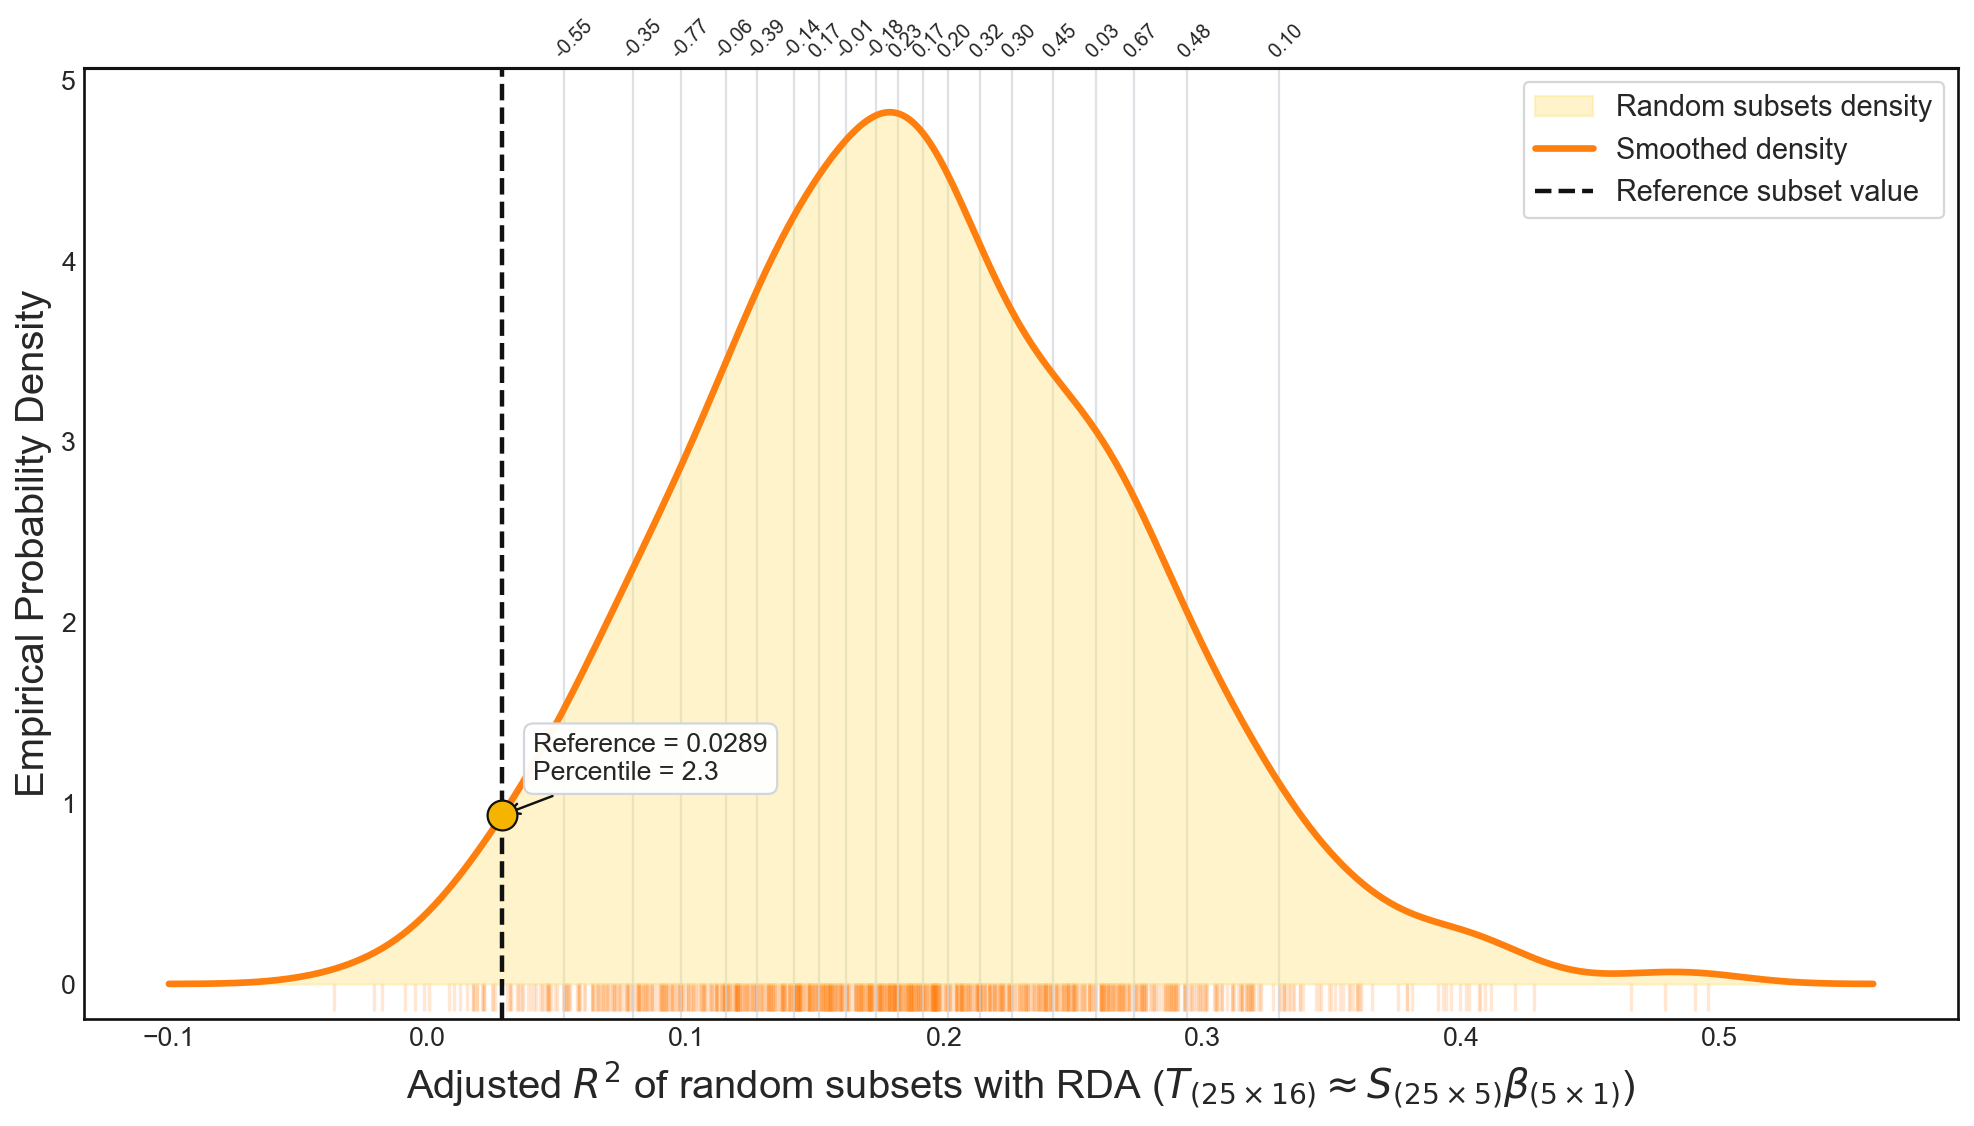

Permutation p-value empirical-distribution figure


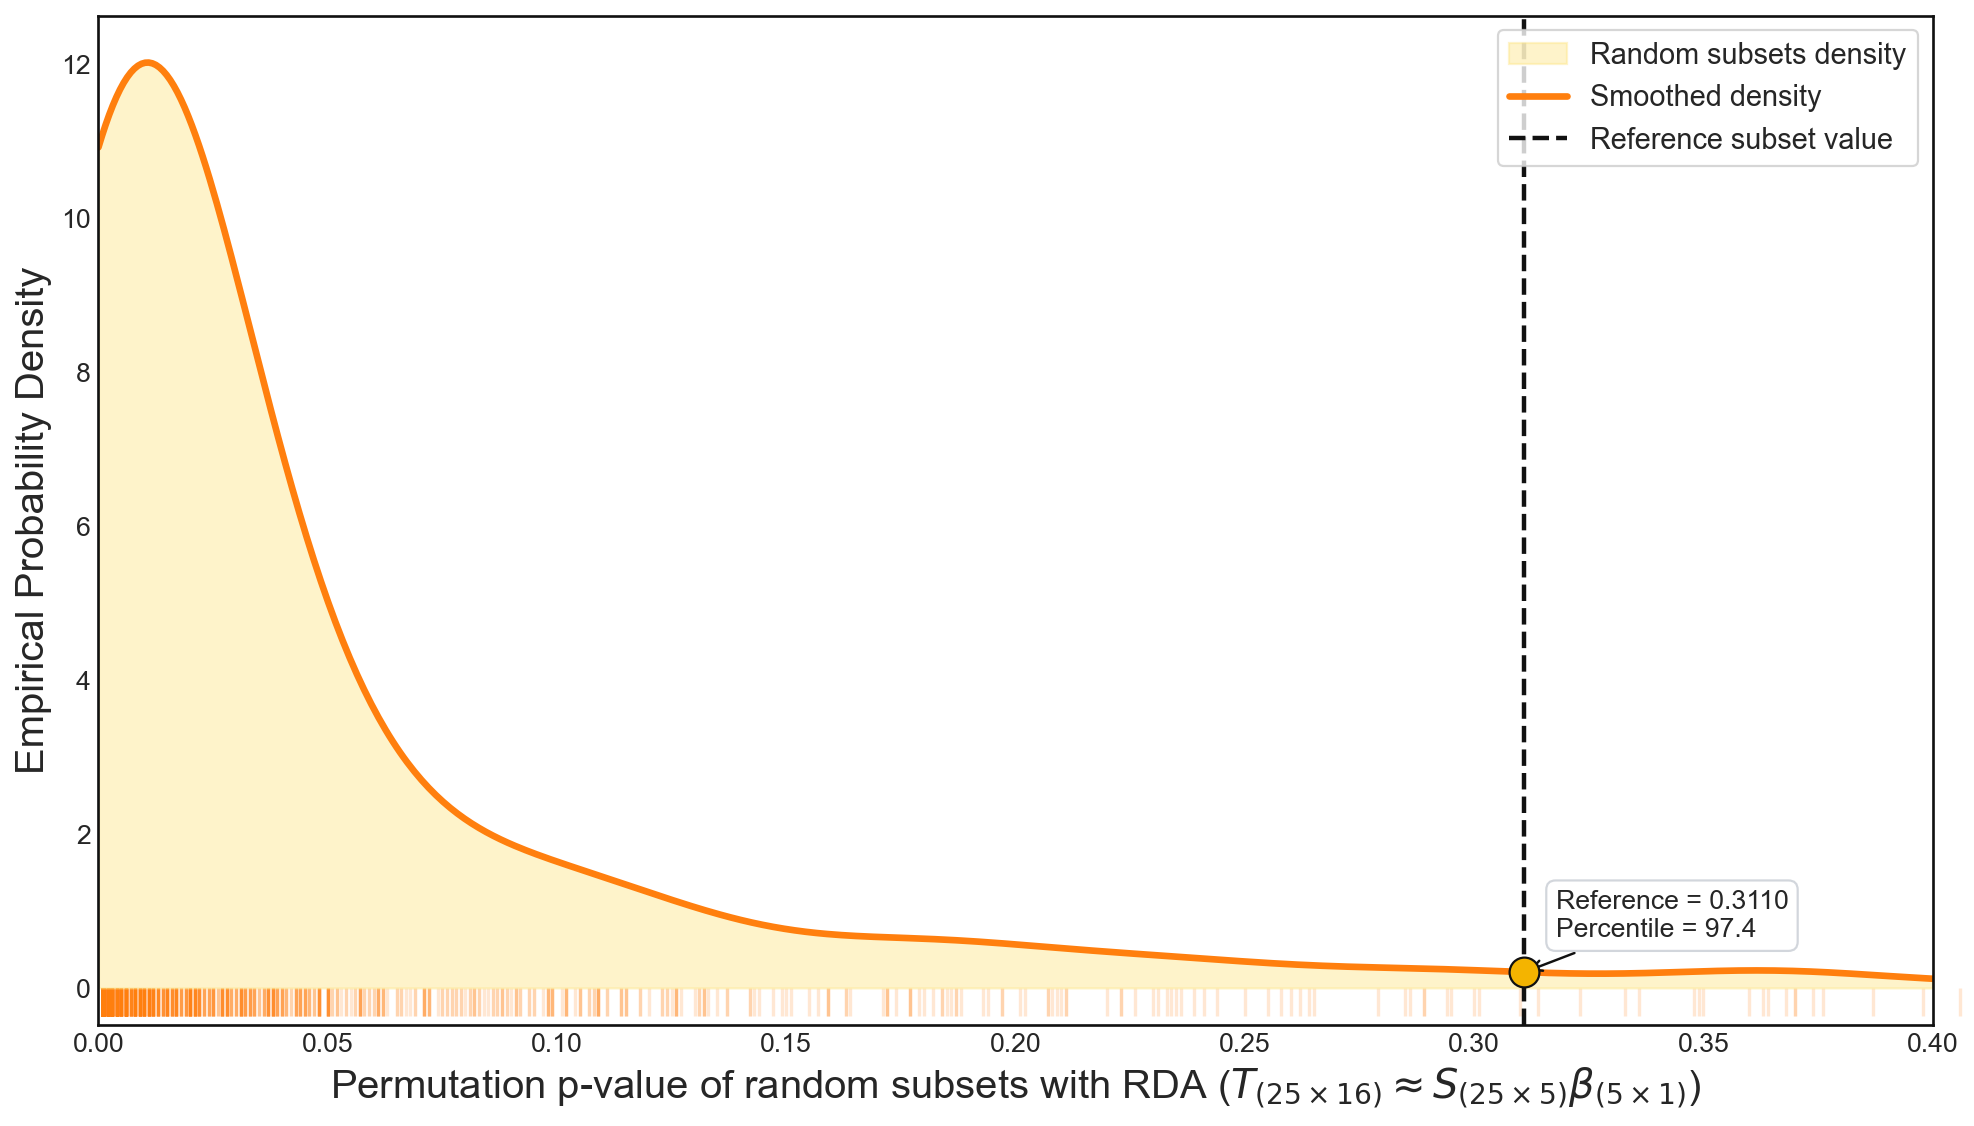

Saved Framework 2 outputs
Result table: ../DetroitRiverCase/results/ch2_fw2_resampling_rda_results.xlsx
Artifact table: ../DetroitRiverCase/artifacts/A2_least_polluted_IDs.xlsx
Adjusted R2 figure: ../DetroitRiverCase/figures/ch2_fw2_empirical_distribution_adj_R2.png
P-value figure: ../DetroitRiverCase/figures/ch2_fw2_empirical_distribution_p_value.png


In [58]:
rda_results_output_table = rda_results
least_site_ids_output_table = pd.DataFrame({SITE_ID_COLUMN: least_site_ids})
distribution_summary_output_table = distribution_summary
adj_r2_distribution_output_figure = fig_adj_r2
p_value_distribution_output_figure = fig_p_value

print("RDA resampling results")
display(rda_results_output_table.head())
rda_results_output_table.to_excel(RESULTS_DIR / "ch2_fw2_resampling_rda_results.xlsx", index=False)

print("Least-polluted/reference site IDs")
display(least_site_ids_output_table.head())
least_site_ids_output_table.to_excel(ARTIFACT_DIR / "A2_least_polluted_IDs.xlsx", index=False)

print("Reference position within the random background")
display(distribution_summary_output_table)

print("Adjusted R2 empirical-distribution figure")
display(adj_r2_distribution_output_figure)
adj_r2_distribution_output_figure.savefig(FIGURE_DIR / "ch2_fw2_empirical_distribution_adj_R2.png", dpi=300, bbox_inches="tight")

print("Permutation p-value empirical-distribution figure")
display(p_value_distribution_output_figure)
p_value_distribution_output_figure.savefig(FIGURE_DIR / "ch2_fw2_empirical_distribution_p_value.png", dpi=300, bbox_inches="tight")

print("Saved Framework 2 outputs")
print(f"Result table: {RESULTS_DIR / 'ch2_fw2_resampling_rda_results.xlsx'}")
print(f"Artifact table: {ARTIFACT_DIR / 'A2_least_polluted_IDs.xlsx'}")
print(f"Adjusted R2 figure: {FIGURE_DIR / 'ch2_fw2_empirical_distribution_adj_R2.png'}")
print(f"P-value figure: {FIGURE_DIR / 'ch2_fw2_empirical_distribution_p_value.png'}")

# Optional extension: compare multiple subset sizes

This section is disabled by default because it can be computationally expensive. Set `RUN_EXTENSION = True` to run the same RDA resampling comparison for additional values of `m`.

In [83]:
RUN_EXTENSION = False

EXTENSION_M_VALUES_CANDIDATE = [30, 50, 100, 200]
EXTENSION_M_VALUES = [m_value for m_value in EXTENSION_M_VALUES_CANDIDATE if m_value <= N_STUDY_SITES]
EXTENSION_RANDOM_SUBSETS = N_RANDOM_SUBSETS
EXTENSION_PERMUTATIONS = PERMUTATIONS

if RUN_EXTENSION:
    extension_start_time = perf_counter()
    extension_result_frames = []

    for m_index, m_value in enumerate(EXTENSION_M_VALUES, start=1):
        m_start_time = perf_counter()
        extension_result_frames.append(
            run_ranked_subset_rda_for_m(
                m_value=m_value,
                B_value=EXTENSION_RANDOM_SUBSETS,
                permutations_value=EXTENSION_PERMUTATIONS,
                base_seed=RANDOM_STATE + m_value,
                stressor_table=S_c,
                stressor_table_z=S_c_z,
                taxa_table=T_with_site_id,
                score_lookup=score_lookup,
            )
        )
        m_elapsed_seconds = perf_counter() - m_start_time
        total_elapsed_seconds = perf_counter() - extension_start_time
        print(
            f"Finished m={m_value} ({m_index}/{len(EXTENSION_M_VALUES)}) "
            f"in {m_elapsed_seconds:.1f}s; total elapsed {total_elapsed_seconds / 60:.1f} min"
        )

    extension_rda_results = pd.concat(extension_result_frames, ignore_index=True)
    extension_m_summary = summarize_extension_results(extension_rda_results, EXTENSION_M_VALUES)

    extension_figure_path = FIGURE_DIR / "ch2_fw2_extension_adj_R2_by_m.png"

    plot_adj_r2_comparison(
        results_df=extension_rda_results,
        m_values=EXTENSION_M_VALUES,
        output_path=extension_figure_path,
    )

    extension_elapsed_minutes = (perf_counter() - extension_start_time) / 60.0
    print(f"Extension run completed in {extension_elapsed_minutes:.1f} minutes")
    print(f"Saved extension figure to: {extension_figure_path}")
    display(extension_m_summary)
else:
    print(
        "Extension skipped. Set RUN_EXTENSION = True to run the multi-m sensitivity comparison "
        f"for valid {STUDY_CASE_LABEL} sizes: {EXTENSION_M_VALUES}."
    )

Extension skipped. Set RUN_EXTENSION = True to run the multi-m sensitivity comparison for valid Detroit River case study sizes: [30, 50, 100, 200].


Processed 100 random subsets in 2.1s
Processed 200 random subsets in 4.2s
Processed 300 random subsets in 6.3s
Processed 400 random subsets in 8.5s
Processed 500 random subsets in 10.8s
Processed 600 random subsets in 13.3s
Processed 700 random subsets in 15.5s
Processed 800 random subsets in 18.0s
Processed 900 random subsets in 20.1s
Processed 1000 random subsets in 22.2s
Completed 1001 subset summaries in 22.2s
Finished m_ref=15 (1/41) in 23.2s
Processed 100 random subsets in 2.5s
Processed 200 random subsets in 4.8s
Processed 300 random subsets in 7.1s
Processed 400 random subsets in 9.4s
Processed 500 random subsets in 11.7s
Processed 600 random subsets in 14.0s
Processed 700 random subsets in 16.5s
Processed 800 random subsets in 19.1s
Processed 900 random subsets in 21.4s
Processed 1000 random subsets in 23.7s
Completed 1001 subset summaries in 23.7s
Finished m_ref=20 (2/41) in 24.7s
Processed 100 random subsets in 2.5s
Processed 200 random subsets in 4.9s
Processed 300 random s

,m_ref,adj_R2_ref,average_c_ref,permutation_F_ref,p_value_ref,random_adj_R2_mean,random_adj_R2_ci_low,random_adj_R2_ci_high,random_permutation_F_mean,random_permutation_F_ci_low,random_permutation_F_ci_high,random_p_value_mean,random_p_value_ci_low,random_p_value_ci_high,random_p_value_max,random_distribution_B,permutations
0,15,0.027680,-18.690249,1.079711,0.407,0.189401,-0.092651,0.470296,1.766477,0.762574,3.485970,0.165747,0.001,0.713250,0.919,1000,999
1,20,0.046596,-17.557739,1.185719,0.292,0.188046,-0.010973,0.390621,1.965112,0.958754,3.435856,0.095831,0.001,0.510100,0.883,1000,999
2,25,0.028934,-16.488842,1.143020,0.326,0.184542,0.025106,0.350139,2.153563,1.123614,3.586199,0.054614,0.001,0.340050,0.627,1000,999
3,30,0.084227,-15.615713,1.533444,0.110,0.188678,0.048151,0.330434,2.409131,1.293403,3.862327,0.028023,0.001,0.196025,0.715,1000,999
4,35,0.094610,-14.842103,1.710576,0.052,0.184458,0.067360,0.318198,2.594053,1.491131,4.173563,0.015004,0.001,0.102100,0.411,1000,999


Saved adjusted R2 sweep figure to: ../DetroitRiverCase/figures/ch2_fw2_m_ref_sweep_adj_R2.png


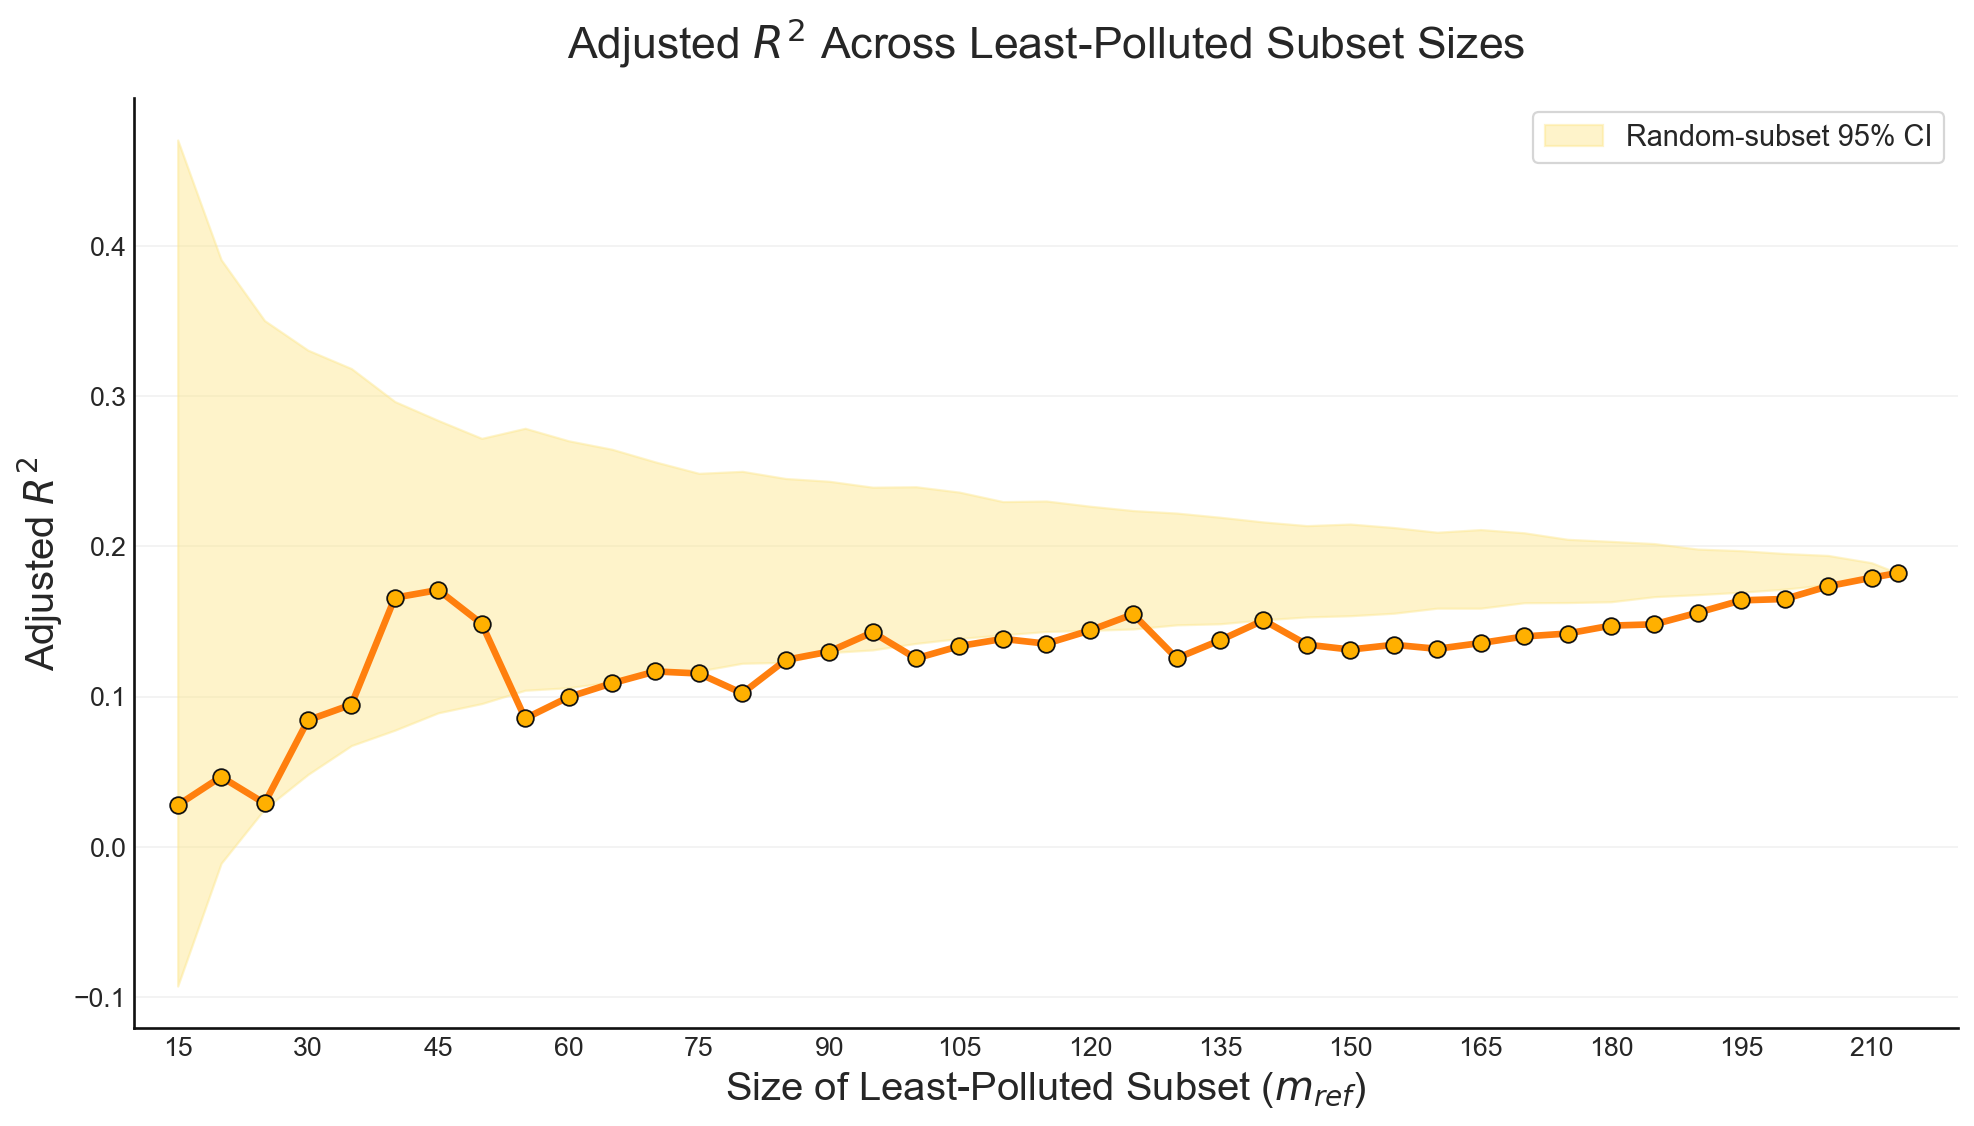

Saved permutation p-value sweep figure to: ../DetroitRiverCase/figures/ch2_fw2_m_ref_sweep_permutation_p_value.png


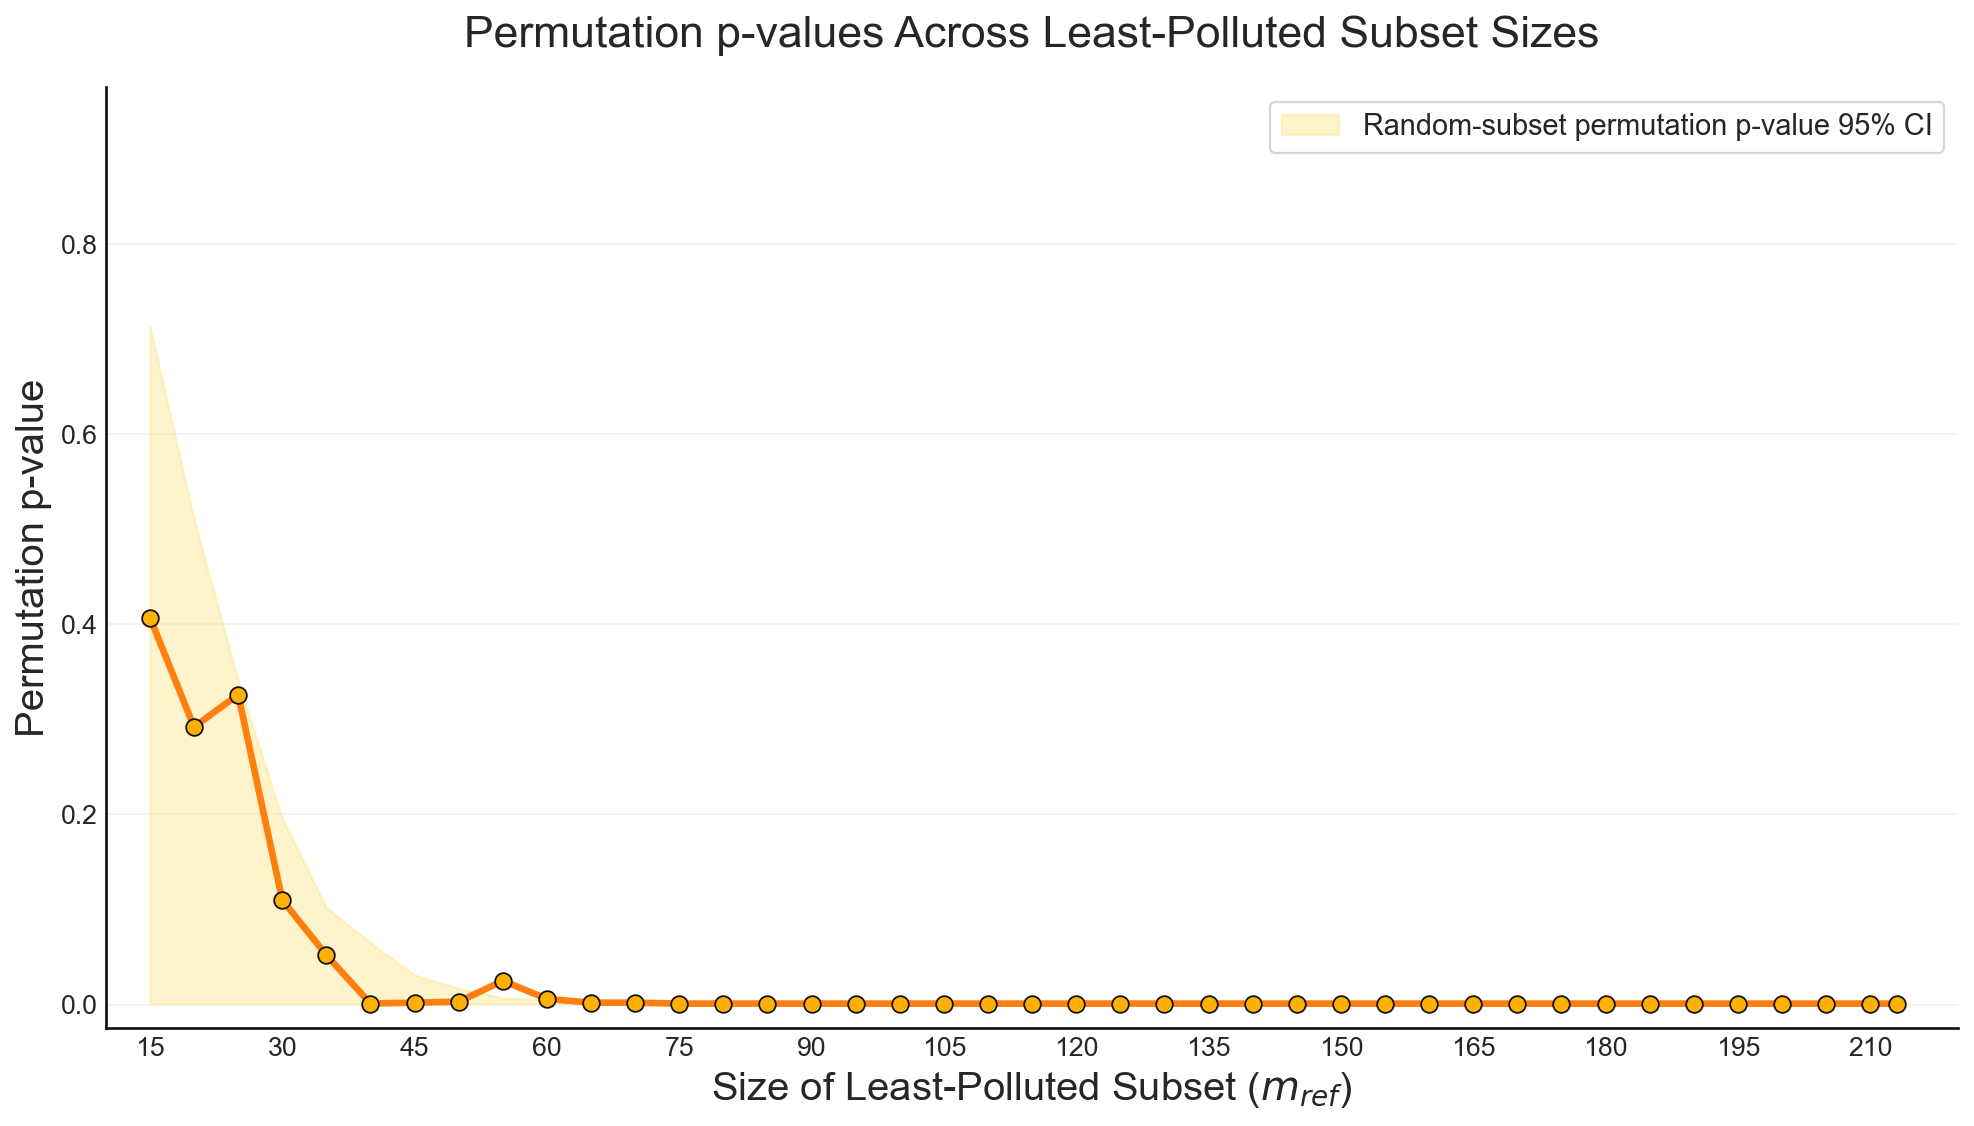

In [65]:
def plot_sweep_metric_summary(
    summary_df: pd.DataFrame,
    x_column: str,
    y_column: str,
    y_label: str,
    title: str,
    line_color: str = "#ff7f0e",
    marker_face_color: str = "#ffb000",
    ci_low_column: str | None = None,
    ci_high_column: str | None = None,
    ci_label: str | None = None,
) -> tuple:
    """Plot one sweep metric against subset size, with an optional random-subset CI band."""
    set_plot_theme()
    fig, ax = plt.subplots(figsize=(12.5, 7.2), dpi=160)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    x_values = summary_df[x_column].to_numpy(dtype=float)
    y_values = summary_df[y_column].to_numpy(dtype=float)

    if (
        ci_low_column is not None
        and ci_high_column is not None
        and summary_df[ci_low_column].notna().any()
        and summary_df[ci_high_column].notna().any()
    ):
        ax.fill_between(
            x_values,
            summary_df[ci_low_column].to_numpy(dtype=float),
            summary_df[ci_high_column].to_numpy(dtype=float),
            color="#fde68a",
            alpha=0.45,
            label=ci_label or "Random-subset 95% CI",
            zorder=1,
        )

    ax.plot(
        x_values,
        y_values,
        color=line_color,
        linewidth=3.0,
        marker="o",
        markersize=7.5,
        markerfacecolor=marker_face_color,
        markeredgecolor="#111111",
        markeredgewidth=0.8,
        zorder=3,
    )

    ax.set_title(title, pad=18)
    ax.set_xlabel(r"Size of Least-Polluted Subset ($m_{ref}$)")
    ax.set_ylabel(y_label)
    # x-ticks
    ax.set_xticks(np.arange(15, 221, 15))
    ax.set_xlim(10, 220)
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if y_column.endswith("p_value_ref") or y_label.lower().startswith("permutation p-value"):
        random_max = float(summary_df["random_p_value_max"].max()) if "random_p_value_max" in summary_df.columns and summary_df["random_p_value_max"].notna().any() else float("nan")
        observed_max = float(np.nanmax(y_values))
        upper_limit = max(value for value in [observed_max, random_max] if np.isfinite(value))
        ax.set_ylim(-0.025, upper_limit * 1.05 if upper_limit > 0 else 0.05)

    if ci_low_column is not None and ci_high_column is not None and summary_df[ci_low_column].notna().any():
        ax.legend(loc="best", frameon=True, facecolor="white")

    fig.tight_layout()
    return fig, ax


def sweep_least_polluted_subset_rda(
    stressor_score_table: pd.DataFrame,
    taxa_table: pd.DataFrame,
    sweeping_step: int,
    random_distribution_B: int,
    permutations: int = PERMUTATIONS,
    random_state: int = RANDOM_STATE,
    site_id_column: str = SITE_ID_COLUMN,
    stressor_columns=None,
    score_column: str = SCORE_COLUMN,
    taxa_columns=None,
    output_path: Path | None = None,
    p_value_output_path: Path | None = None,
) -> dict:
    """Sweep least-polluted subset sizes, run RDA, and compare against random subsets."""
    stressor_columns = list(stressor_columns or STRESSOR_COLUMNS)
    taxa_columns = list(taxa_columns or TAXA_COLUMNS)
    selected_columns = list(dict.fromkeys([*stressor_columns, score_column]))

    validate_required_columns(
        stressor_score_table,
        [site_id_column, *stressor_columns, score_column],
        table_name="stressor-score table",
    )
    validate_required_columns(
        taxa_table,
        [site_id_column, *taxa_columns],
        table_name="taxa table",
    )
    if sweeping_step <= 0:
        raise ValueError("sweeping_step must be positive.")
    if random_distribution_B < 0:
        raise ValueError("random_distribution_B cannot be negative.")

    m_min = 15
    available_site_count = int(len(stressor_score_table))
    m_values = [
        m_value
        for m_value in range(sweeping_step, available_site_count + 1, sweeping_step)
        if m_value >= m_min
    ]
    if available_site_count >= m_min and available_site_count not in m_values:
        m_values.append(available_site_count)
    if not m_values:
        raise ValueError(
            f"No valid subset sizes are available. Increase the study size or lower the minimum model size threshold ({m_min})."
        )

    standardize_columns = list(dict.fromkeys([*stressor_columns, score_column]))
    stressor_table_z = z_score_standardizer(stressor_score_table, numeric_columns=standardize_columns)
    score_lookup = pd.to_numeric(
        stressor_score_table.set_index(site_id_column)[score_column],
        errors="raise",
    )

    summary_rows = []
    all_result_frames = []
    sweep_start_time = perf_counter()

    for m_index, m_value in enumerate(m_values, start=1):
        m_start_time = perf_counter()
        least_site_ids = select_least_stressed_sites(
            stressor_score_table,
            score_column=score_column,
            m=m_value,
            site_id_column=site_id_column,
        )
        S_ref = slice_matrix_by_site_ids(
            stressor_table_z,
            site_ids=least_site_ids,
            site_id_column=site_id_column,
            value_columns=selected_columns,
        )
        T_ref = slice_matrix_by_site_ids(
            taxa_table,
            site_ids=least_site_ids,
            site_id_column=site_id_column,
            value_columns=taxa_columns,
        )

        if random_distribution_B > 0:
            random_site_id_sets = sample_random_site_subsets(
                stressor_score_table[site_id_column],
                m=m_value,
                B=random_distribution_B,
                random_state=random_state + m_value,
            )
            S_randoms, T_randoms = materialize_subset_matrices(
                site_id_sets=random_site_id_sets,
                stressor_table_z=stressor_table_z,
                taxa_table=taxa_table,
                selected_columns=selected_columns,
                taxa_columns=taxa_columns,
                site_id_column=site_id_column,
            )
            rda_results_m = run_reference_vs_random_rda(
                least_site_ids=least_site_ids,
                random_site_id_sets=random_site_id_sets,
                T_ref=T_ref,
                S_ref=S_ref,
                T_randoms=T_randoms,
                S_randoms=S_randoms,
                score_lookup=score_lookup,
                m=m_value,
                stressor_columns=stressor_columns,
                permutations=permutations,
                random_state=random_state + m_value,
            )
        else:
            reference_row = summarize_subset_rda(
                subset_id="ref",
                subset_type="least_ranked",
                subset_site_ids=least_site_ids.tolist(),
                taxa_df=T_ref,
                descriptor_df=S_ref,
                score_lookup=score_lookup,
                m=m_value,
                stressor_columns=stressor_columns,
                permutations=permutations,
            )
            rda_results_m = pd.DataFrame([reference_row])

        reference_result = rda_results_m.loc[rda_results_m["subset_type"] == "least_ranked"].iloc[0]
        random_results_m = rda_results_m.loc[rda_results_m["subset_type"] == "random"].copy()

        summary_rows.append(
            {
                "m_ref": int(m_value),
                "adj_R2_ref": float(reference_result["adj_R2_str"]),
                "average_c_ref": float(reference_result["average_c"]),
                "permutation_F_ref": float(reference_result["permutation_F_stressor"]),
                "p_value_ref": float(reference_result["p_value_stressor"]),
                "random_adj_R2_mean": float(random_results_m["adj_R2_str"].mean()) if not random_results_m.empty else np.nan,
                "random_adj_R2_ci_low": float(random_results_m["adj_R2_str"].quantile(0.025)) if not random_results_m.empty else np.nan,
                "random_adj_R2_ci_high": float(random_results_m["adj_R2_str"].quantile(0.975)) if not random_results_m.empty else np.nan,
                "random_permutation_F_mean": float(random_results_m["permutation_F_stressor"].mean()) if not random_results_m.empty else np.nan,
                "random_permutation_F_ci_low": float(random_results_m["permutation_F_stressor"].quantile(0.025)) if not random_results_m.empty else np.nan,
                "random_permutation_F_ci_high": float(random_results_m["permutation_F_stressor"].quantile(0.975)) if not random_results_m.empty else np.nan,
                "random_p_value_mean": float(random_results_m["p_value_stressor"].mean()) if not random_results_m.empty else np.nan,
                "random_p_value_ci_low": float(random_results_m["p_value_stressor"].quantile(0.025)) if not random_results_m.empty else np.nan,
                "random_p_value_ci_high": float(random_results_m["p_value_stressor"].quantile(0.975)) if not random_results_m.empty else np.nan,
                "random_p_value_max": float(random_results_m["p_value_stressor"].max()) if not random_results_m.empty else np.nan,
                "random_distribution_B": int(random_distribution_B),
                "permutations": int(permutations),
            }
        )
        all_result_frames.append(rda_results_m)

        elapsed_seconds = perf_counter() - m_start_time
        print(
            f"Finished m_ref={m_value} ({m_index}/{len(m_values)}) in {elapsed_seconds:.1f}s"
        )

    summary_df = pd.DataFrame(summary_rows)
    detailed_results_df = pd.concat(all_result_frames, ignore_index=True)

    fig_adj_r2, ax_adj_r2 = plot_sweep_metric_summary(
        summary_df=summary_df,
        x_column="m_ref",
        y_column="adj_R2_ref",
        y_label="Adjusted $R^2$",
        title="Adjusted $R^2$ Across Least-Polluted Subset Sizes",
        ci_low_column="random_adj_R2_ci_low",
        ci_high_column="random_adj_R2_ci_high",
        ci_label="Random-subset 95% CI",
    )

    fig_p_value, ax_p_value = plot_sweep_metric_summary(
        summary_df=summary_df,
        x_column="m_ref",
        y_column="p_value_ref",
        y_label="Permutation p-value",
        title="Permutation p-values Across Least-Polluted Subset Sizes",
        ci_low_column="random_p_value_ci_low",
        ci_high_column="random_p_value_ci_high",
        ci_label="Random-subset permutation p-value 95% CI",
    )

    total_minutes = (perf_counter() - sweep_start_time) / 60.0
    print(f"Completed least-polluted subset sweep in {total_minutes:.1f} minutes")

    return {
        "summary": summary_df,
        "detailed_results": detailed_results_df,
        "figure": fig_adj_r2,
        "axis": ax_adj_r2,
        "p_value_figure": fig_p_value,
        "p_value_axis": ax_p_value,
        "m_values": summary_df["m_ref"].tolist(),
    }


M_REF_SWEEP_STEP = 5
M_REF_SWEEP_RANDOM_B = 1000
M_REF_SWEEP_PERMUTATIONS = PERMUTATIONS
M_REF_SWEEP_RANDOM_STATE = RANDOM_STATE + 202
M_REF_SWEEP_FIGURE_PATH = FIGURE_DIR / "ch2_fw2_m_ref_sweep_adj_R2.png"
M_REF_SWEEP_PVALUE_FIGURE_PATH = FIGURE_DIR / "ch2_fw2_m_ref_sweep_permutation_p_value.png"

m_ref_sweep_outputs = sweep_least_polluted_subset_rda(
    stressor_score_table=S_c,
    taxa_table=T_with_site_id,
    sweeping_step=M_REF_SWEEP_STEP,
    random_distribution_B=M_REF_SWEEP_RANDOM_B,
    permutations=M_REF_SWEEP_PERMUTATIONS,
    random_state=M_REF_SWEEP_RANDOM_STATE,
)

m_ref_sweep_summary = m_ref_sweep_outputs["summary"]
m_ref_sweep_detailed_results = m_ref_sweep_outputs["detailed_results"]

print("Least-polluted subset sweep summary")
display(m_ref_sweep_summary.head())
print(f"Saved adjusted R2 sweep figure to: {M_REF_SWEEP_FIGURE_PATH}")
display(m_ref_sweep_outputs["figure"])
print(f"Saved permutation p-value sweep figure to: {M_REF_SWEEP_PVALUE_FIGURE_PATH}")
display(m_ref_sweep_outputs["p_value_figure"])
plt.close(m_ref_sweep_outputs["figure"])
plt.close(m_ref_sweep_outputs["p_value_figure"])

# Execution summary

After a complete corridor-case run, this notebook produces:

```text
../results/ch2_fw2_resampling_rda_results.xlsx
../artifacts/A2_least_polluted_IDs.xlsx
../figures/ch2_fw2_empirical_distribution_adj_R2.png
../figures/ch2_fw2_empirical_distribution_p_value.png
# Optional extension output
../figures/ch2_fw2_extension_adj_R2_by_m.png
```

When `STUDY_CASE = "DR"`, the same output filenames are written under:

```text
../DetroitRiverCase/results/
../DetroitRiverCase/artifacts/
../DetroitRiverCase/figures/
```